# Laboratorul 10

Rezolvați exercițiile din îndrumarul PDF. La final, rulați tot notebook-ul și asigurați-vă că nu aveți erori. Salvați fișierul și încărcați-l în assignment-ul de Teams corespunzător grupei voastre.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import dictlearn
from sklearn.feature_extraction.image import extract_patches_2d
from matplotlib import image
from sklearn.preprocessing import normalize
from dictlearn import DictionaryLearning
from dictlearn import methods
from sklearn.feature_extraction.image import reconstruct_from_patches_2d

In [2]:
p = 8           # dimensiunea unui patch (numar de pixeli)
s = 6           # sparsitatea
N = 1000        # numarul total de patch-uri
n = 256         # numarul de atomi din dictionar
K = 50          # numarul de iteratii DL
sigma = 0.075   # deviatia standard a zgomotului

# Exercitiul 1

## a)

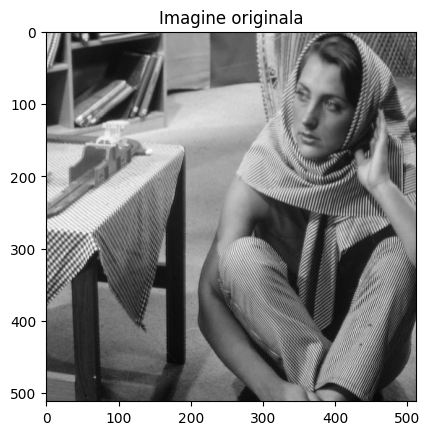

In [3]:
I = image.imread('barbara.png')
if I.dtype != 'float32':
    I = I / 255.0

plt.imshow(I, cmap='gray')
plt.title("Imagine originala")
plt.show()


## b)

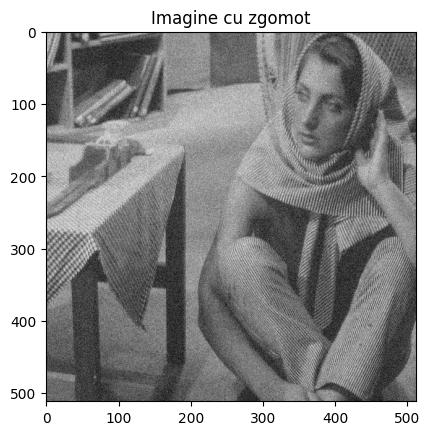

In [4]:
sigma = 0.075
Inoisy = I + sigma * np.random.randn(I.shape[0], I.shape[1])

plt.imshow(Inoisy, cmap='gray')
plt.title("Imagine cu zgomot")
plt.show()


## c)

In [5]:
p = 8
Ynoisy = extract_patches_2d(Inoisy, (p, p))
print("Dimensiunea initiala a patch-urilor:", Ynoisy.shape)

Ynoisy = Ynoisy.reshape(Ynoisy.shape[0], -1)
print("Dimensiunea dupa vectorizare:", Ynoisy.shape)

Ynoisy = Ynoisy.T
media_patch = np.mean(Ynoisy, axis=0)
Ynoisy -= media_patch

Dimensiunea initiala a patch-urilor: (255025, 8, 8)
Dimensiunea dupa vectorizare: (255025, 64)


## d)

In [6]:
N = 1000
indices = np.random.choice(Ynoisy.shape[1], N, replace=False)
Y = Ynoisy[:, indices]

# Exercitiul 2

## a)

In [7]:
n = 256
D0 = np.random.randn(p * p, n)
D0 = normalize(D0, axis=0, norm='max')

## b)

In [8]:
K = 50
dl = DictionaryLearning(
    n_components=n,
    max_iter=K,
    fit_algorithm='ksvd',
    n_nonzero_coefs=s,
    code_init=None,
    dict_init=D0,
    params=None,
    data_sklearn_compat=False
)
dl.fit(Y)
D = dl.D_


/home/cosmin/anaconda3/lib/python3.11/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


# Exercitiul 3

## a)

In [9]:
Xc, err = methods.omp(Ynoisy, D, n_nonzero_coefs=6)

## b)

In [10]:
Yc = D @ Xc
Yc += media_patch

## c)

In [11]:
Yc = Yc.T
Yc = Yc.reshape(-1, p, p)
Ic = reconstruct_from_patches_2d(Yc, I.shape)

# Exercitiul 4

## a) 

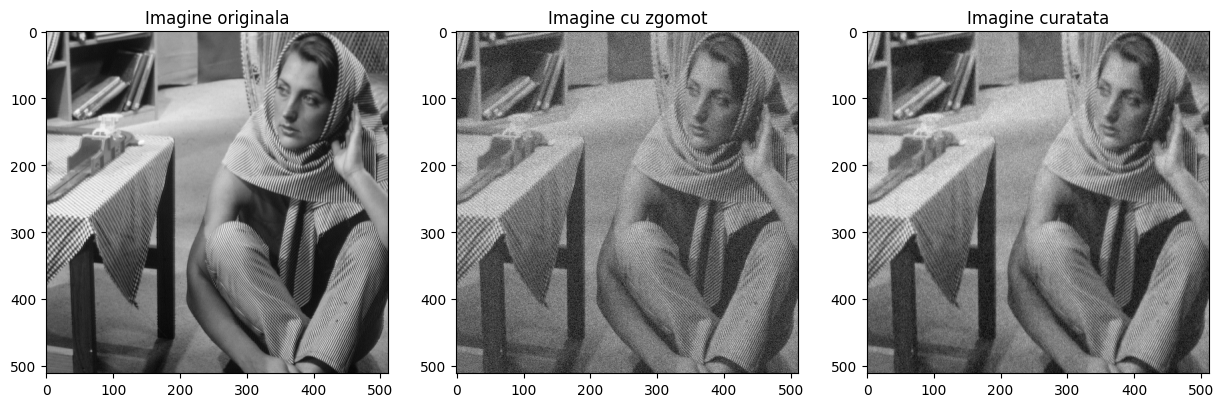

In [12]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(I, cmap='gray')
plt.title("Imagine originala")

plt.subplot(1, 3, 2)
plt.imshow(Inoisy, cmap='gray')
plt.title("Imagine cu zgomot")

plt.subplot(1, 3, 3)
plt.imshow(Ic, cmap='gray')
plt.title("Imagine curatata")
plt.show()

## b)

In [13]:
def psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0
    return 20 * np.log10(max_pixel / np.sqrt(mse))

psnr_noisy = psnr(I, Inoisy)
psnr_cleaned = psnr(I, Ic)
print(f"PSNR (noisy vs original): {psnr_noisy:.2f}")
print(f"PSNR (cleaned vs original): {psnr_cleaned:.2f}")

PSNR (noisy vs original): 22.49
PSNR (cleaned vs original): 27.01
